In [5]:
#### Python script for dividing any shapely polygon into smaller equal sized polygons

import numpy as np
from shapely.ops import split
from shapely import LineString
import geopandas
from shapely.geometry import MultiPolygon, Polygon

def rhombus(square):
    """
    Naively transform the square into a Rhombus at a 45 degree angle
    """
    coords = square.boundary.coords.xy
    xx = list(coords[0])
    yy = list(coords[1])
    radians = 1
    points = list(zip(xx, yy))
    Rhombus = Polygon(
        [
            points[0],
            points[1],
            points[3],
            ((2 * points[3][0]) - points[2][0], (2 * points[3][1]) - points[2][1]),
            points[4],
        ]
    )
    return Rhombus


def get_squares_from_rect(RectangularPolygon, side_length=0.0025):
    """
    Divide a Rectangle (Shapely Polygon) into squares of equal area.

    `side_length` : required side of square

    """
    rect_coords = np.array(RectangularPolygon.boundary.coords.xy)
    y_list = rect_coords[1]
    x_list = rect_coords[0]
    y1 = min(y_list)
    y2 = max(y_list)
    x1 = min(x_list)
    x2 = max(x_list)
    width = x2 - x1
    height = y2 - y1

    xcells = int(np.round(width / side_length))
    ycells = int(np.round(height / side_length))

    yindices = np.linspace(y1, y2, ycells + 1)
    xindices = np.linspace(x1, x2, xcells + 1)
    horizontal_splitters = [
        LineString([(x, yindices[0]), (x, yindices[-1])]) for x in xindices
    ]
    vertical_splitters = [
        LineString([(xindices[0], y), (xindices[-1], y)]) for y in yindices
    ]
    result = RectangularPolygon
    for splitter in vertical_splitters:
        result = MultiPolygon(split(result, splitter))
    for splitter in horizontal_splitters:
        result = MultiPolygon(split(result, splitter))
    square_polygons = list(result)

    return square_polygons


def split_polygon(G, side_length=0.025, shape="square", thresh=0.9):
    """
    Using a rectangular envelope around `G`, creates a mesh of squares of required length.
    
    Removes non-intersecting polygons. 
            

    Args:
    
    - `thresh` : Range - [0,1]

        This controls - the number of smaller polygons at the boundaries.
        
        A thresh == 1 will only create (or retain) smaller polygons that are 
        completely enclosed (area of intersection=area of smaller polygon) 
        by the original Geometry - `G`.
        
        A thresh == 0 will create (or retain) smaller polygons that 
        have a non-zero intersection (area of intersection>0) with the
        original geometry - `G` 

    - `side_length` : Range - (0,infinity)
        side_length must be such that the resultant geometries are smaller 
        than the original geometry - `G`, for a useful result.

        side_length should be >0 (non-zero positive)

    - `shape` : {square/rhombus}
        Desired shape of subset geometries. 


    """
    assert side_length>0, "side_length must be a float>0"
    Rectangle    = G.envelope
    squares      = get_squares_from_rect(Rectangle, side_length=side_length)
    SquareGeoDF  = geopandas.GeoDataFrame(squares).rename(columns={0: "geometry"})
    Geoms        = SquareGeoDF[SquareGeoDF.intersects(G)].geometry.values
    if shape == "rhombus":
        Geoms = [rhombus(g) for g in Geoms]
        geoms = [g for g in Geoms if ((g.intersection(G)).area / g.area) >= thresh]
    elif shape == "square":
        geoms = [g for g in Geoms if ((g.intersection(G)).area / g.area) >= thresh]
    return geoms

In [2]:
# Reading geometric data

geo_filepath = "../../coordinates/Region_prediction/Xenium-data-coordinates-filtered_SD1-ZT13.geojson"
GeoDF        = geopandas.read_file(geo_filepath)



In [6]:
GeoDF

,cell_type_newnum_final,geometry
0,VLMC,"MULTIPOLYGON (((1720 760, 1680 760, 1680 800, ..."
1,CTX,"POLYGON ((640 2640, 600 2640, 600 2680, 600 27..."
2,AMY,"MULTIPOLYGON (((1880 1360, 1840 1360, 1840 140..."
3,SCH,"POLYGON ((3960 1160, 4000 1160, 4000 1200, 400..."
4,AHN,"MULTIPOLYGON (((3440 1120, 3440 1160, 3440 120..."
5,LHA,"MULTIPOLYGON (((2480 1360, 2480 1400, 2480 144..."
6,STR,"MULTIPOLYGON (((1360 2280, 1360 2320, 1360 236..."
7,Ependymal,"MULTIPOLYGON (((3520 3200, 3480 3200, 3480 324..."
8,PVH,"MULTIPOLYGON (((3240 1560, 3280 1560, 3320 156..."
9,PVT,"POLYGON ((4160 2560, 4160 2600, 4160 2640, 412..."


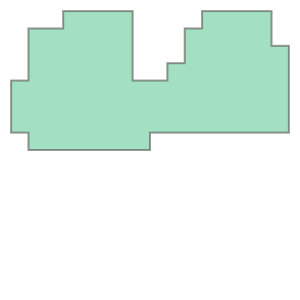

In [19]:
G = GeoDF.geometry[3]
G

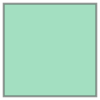

In [26]:
d = Polygon([(0,0),(0,5),(5,5),(5,0),(0,0)])
d

In [32]:
# Selecting random shapely-geometry

squares   = split_polygon(d, shape='square',thresh=0.5,side_length=0.1)
# rhombuses = split_polygon(G,shape='rhombus',thresh=0.5,side_length=500)

TypeError: 'MultiPolygon' object is not iterable

In [ ]:
squares